Regressione logistica

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

dataset

In [ ]:
data=load_breast_cancer(as_frame=True)
df=data.frame
display(df.tail())
X=df[data.feature_names]
y=df["target"]
print(X.shape)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


(569, 30)


Applica la regressine logistica per classificare i pazienti o nella classe 0 o nella classe 1

In [7]:
model=LogisticRegression(max_iter=5_000)
model.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


stampiamo informazioni

In [10]:
print(f"Intercetta: {model.intercept_[0]}")
print(f"Coefficienti principali (5):")
for name,coef in zip(data.feature_names[:5],model.coef_[0][:5]):
    print(f"{name}:{coef:.3f}")

Intercetta: 28.112272686562854
Coefficienti principali (5):
mean radius:1.009
mean texture:0.181
mean perimeter:-0.276
mean area:0.023
mean smoothness:-0.177


In [11]:
y_pred=model.predict(X)

Controllo le corrette

In [15]:
corrette=np.sum(y==y_pred)
tot=len(y)
accurancy=corrette/tot
print(f"Etichette corrette: {corrette}/{tot}")
print(f"Accuracy: {accurancy*100:.2f}")

Etichette corrette: 545/569
Accuracy: 95.78


plot delle etichette predette ed etichette reali

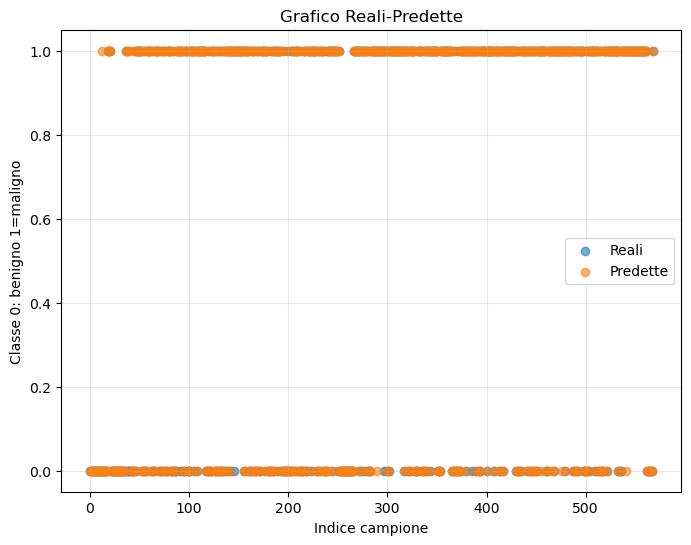

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(range(tot),y,label="Reali",alpha=0.6)
plt.scatter(range(tot),y_pred,label="Predette",alpha=0.6)
plt.title("Grafico Reali-Predette")
plt.xlabel("Indice campione")
plt.ylabel("Classe 0: benigno 1=maligno")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Dal grafico precedente si vede che le reali sono completamente sovrapposte alla predete, pertanto buono il modello
Ho solo valori 0 e valori 1 perchè siamo nel caso della classificazione binaria, pertanto ho solo due rette, un dato appartiene alla classe 0 o appartiene alla classe 1. Il grafico è abbastanza pulito, anche dalla statistica diceva che solo 24 erano i casi di punti erroneamente attribuiti ad una classe (sono i punti in blu che si vedono)

Grafico per relazione tra le feature più importante e la label. Avevamo visto prima che la feature più importante è mean radius:1.009

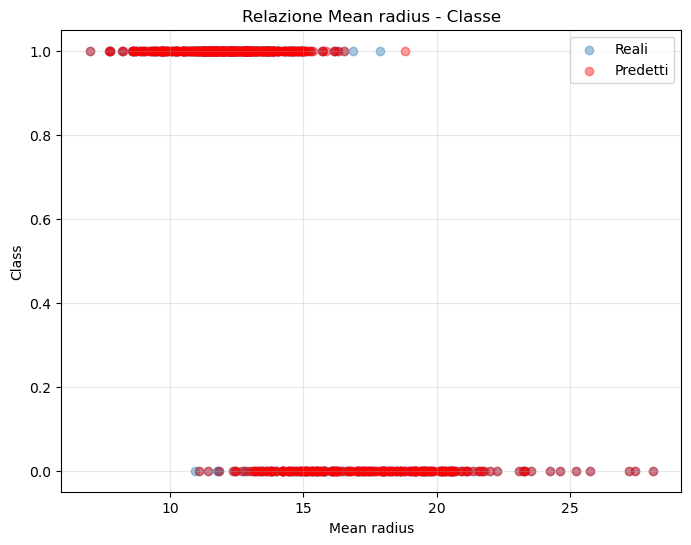

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(df["mean radius"],y,label="Reali",alpha=0.4)
plt.scatter(df["mean radius"],y_pred,label="Predetti",alpha=0.4, color="red")
plt.title("Relazione Mean radius - Classe")
plt.xlabel("Mean radius")
plt.ylabel("Class")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Informazione nascosta: Per la classe 0 ci sono più valori che hanno min radius (raggio medio della massa tumorale) più grande
Mentre le classi 1 il raggio medio della massa tumorale è più ridotto